In [1958]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage
import cv2
import random
import itertools
from collections import Counter

In [142]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [403]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


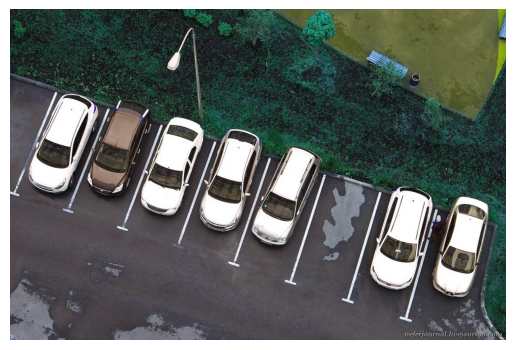

In [2587]:
# --- EASY
#(set_name, image_name) = ("easy", "29.png")           # the cartoonish one. 
#(set_name, image_name) = ("easy", "not_that_easy.jpg") # the fake cars ones with the concrete lines.
#(set_name, image_name) = ("easy", "easy.jpg")         # fake empty one with the bits of lines at the bottom
#(set_name, image_name) = ("easy", "20.png")           # The mirror one, real cars

# --- MEDIUM
#set_name, image_name) = ("medium", "12.png")  # the one with the grass dividers on either side
#(set_name, image_name) = ("medium", "30.png")  # slightly askew lines
#(set_name, image_name) = ("medium", "31.png")  # top and bottom rows.

# --- HARD
#(set_name, image_name) = ("hard", "frame600.jpg") # dangan crop.
#(set_name, image_name) = ("hard", "frame1.jpg")   # dangan large.  Need to use the small scale flag.
(set_name, image_name) = ("hard", "21.png")       # the rotated image


image = images[set_name][image_name]
image = np.array(image)   
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
plt.imshow(image)
plt.axis('off')
plt.show()

In [2588]:
def mask_out_colour(img, color_hsv_deg=(206.7, 36.2, 68.2), h_tolerance=15, s_tolerance=15, v_tolerance=15, debug=False):
        # Unpack your HSV (0–360, 0–100, 0–100)
        H_deg, S_pct, V_pct = color_hsv_deg

        # Convert to OpenCV HSV ranges:
        # H: [0,179], S: [0,255], V: [0,255]
        H = int(H_deg / 2.0)
        S = int(S_pct * 2.55)
        V = int(V_pct * 2.55)

        # Convert tolerances from "deg / percentage" to OpenCV units
        h_tol_cv = int(h_tolerance / 2.0)
        s_tol_cv = int(s_tolerance * 2.55)
        v_tol_cv = int(v_tolerance * 2.55)

        lower = np.array([
            max(H - h_tol_cv, 0),
            max(S - s_tol_cv, 0),
            max(V - v_tol_cv, 0)
        ], dtype=np.uint8)

        upper = np.array([
            min(H + h_tol_cv, 179),
            min(S + s_tol_cv, 255),
            min(V + v_tol_cv, 255)
        ], dtype=np.uint8)

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower, upper)

        if debug:
            print("Target HSV (OpenCV):", (H, S, V))
            print("Lower HSV bound    :", lower)
            print("Upper HSV bound    :", upper)
            print("Nonzero mask px    :", np.count_nonzero(mask))

        # Replace masked pixels with white in BGR
        masked_img = img.copy()
        masked_img[mask > 0] = (255, 255, 255)
        return masked_img, mask
                
        return masked_img, mask


nonzero: 5649
Masked area: 0.70%
Mask rejected (too large).


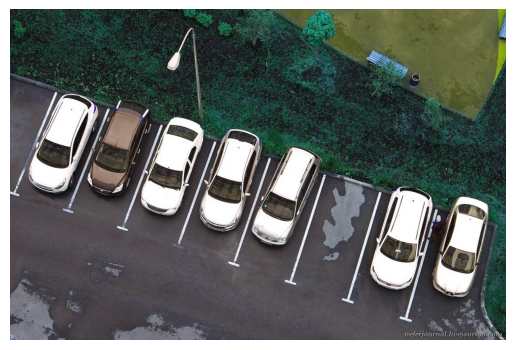

In [2589]:
def pre_mask(image):
    masked_img, mask = mask_out_colour(image)

    print("nonzero:", np.count_nonzero(mask))
    # Mask uses 255 for masked → convert to boolean
    mask_bool = mask > 0

    masked_pixels = np.sum(mask_bool)
    total_pixels  = mask_bool.size
    masked_ratio  = masked_pixels / total_pixels

    print(f"Masked area: {masked_ratio*100:.2f}%")
    
    return masked_img, masked_ratio

def apply_colour_correction_to_dangan(image, mask_threshold=0.0065):
    masked_img, masked_ratio = pre_mask(image)

    if masked_ratio <= mask_threshold:
        print("Mask accepted.")
        return masked_img
    else:
        print("Mask rejected (too large).")
        return image

masked_image = apply_colour_correction_to_dangan(image)
plt.imshow(masked_image)
plt.axis('off')
plt.show()

Full resolution edge density: 0.2453069577080491
Noisy — testing downsample attempt...
Downsampled edge density: 0.2110231923601637
Downsampled result is cleaner — using it.


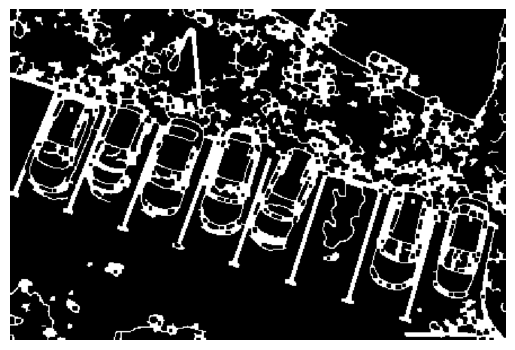

In [2590]:
def step_1(image):

    # --------------------------------------------
    # 1. Greyscale
    # --------------------------------------------
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # --------------------------------------------
    # 2. Gaussian smoothing (true Canny blur)
    # --------------------------------------------
    grey_blur = cv2.GaussianBlur(grey, (3,3), 2)

    # --------------------------------------------
    # 3. Auto-Canny thresholds
    # --------------------------------------------
    med = np.median(grey_blur)
    sigma = 0.33
    low = int(max(0,  (1.0 - sigma) * med))
    high = int(min(255,(1.0 + sigma) * med))

    edges = cv2.Canny(grey_blur, low, high)

    # --------------------------------------------
    # 4. Morphological CLOSE to reconnect parking lines
    # --------------------------------------------
    close_kernel = np.ones((3,3), np.uint8)
    edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, close_kernel)

    return edges_closed


def edge_density(mask):
    """Compute white-pixel ratio in an edge mask."""
    total_pixels = mask.size
    white_pixels = np.count_nonzero(mask)
    return white_pixels / total_pixels


def smart_edges(image):

    # 1. First attempt (no downsample)
    edges = step_1(image)
    ratio_full = edge_density(edges)
    print("Full resolution edge density:", ratio_full)

    # If it's already fine → return it
    if ratio_full <= 0.09:
        return edges

    print("Noisy — testing downsample attempt...")

    # 2. Try downsampled version
    small = cv2.resize(image, (0,0), fx=0.4, fy=0.4)
    edges_small = step_1(small)

    # Upscale back for comparison
    edges_up = cv2.resize(edges_small, (image.shape[1], image.shape[0]),
                          interpolation=cv2.INTER_NEAREST)

    ratio_small = edge_density(edges_up)
    print("Downsampled edge density:", ratio_small)

    # --------------------------------------------
    # NEW LOGIC:
    # Only use downsampled result if it REDUCES noise
    # --------------------------------------------
    if ratio_small < ratio_full:
        print("Downsampled result is cleaner — using it.")
        return edges_up
    else:
        print("Downsampled result is noisier — keeping original.")
        return edges

edges = smart_edges(masked_image)
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

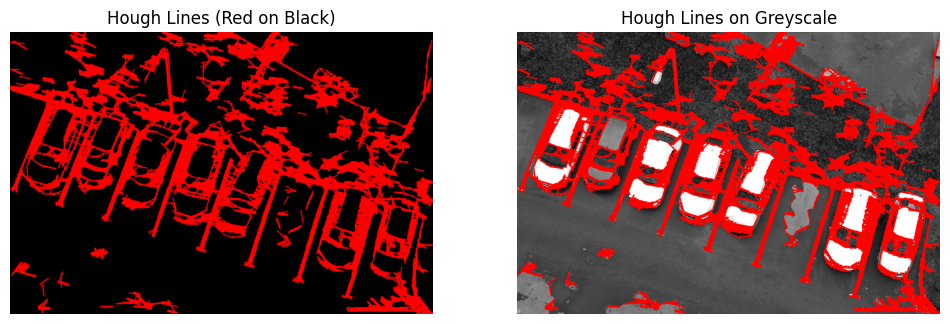

In [2591]:
def step_2_hough_lines(image, edges, percent_of_height=0.03):
    """
    image: original BGR image
    edges: edge mask from step_1 or smart_edges
    percent_of_height: fraction of the image height used for minLineLength
    """

    # --------------------------------------------
    # 1. Calculate size-dependent parameters
    # --------------------------------------------
    h, w = edges.shape[:2]

    min_line_length = int(h * percent_of_height)
    max_line_gap    = int(min_line_length / 2)

    # --------------------------------------------
    # 2. Hough Lines P
    # --------------------------------------------
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    # --------------------------------------------
    # 3. Output canvases
    # --------------------------------------------
    line_image_black = np.zeros((h, w, 3), dtype=np.uint8)

    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    grey_bgr = cv2.cvtColor(grey, cv2.COLOR_GRAY2BGR)

    # --------------------------------------------
    # 4. Draw lines
    # --------------------------------------------
    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            cv2.line(line_image_black, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.line(grey_bgr,        (x1, y1), (x2, y2), (0, 0, 255), 2)

    return line_image_black, grey_bgr, lines

black_lines, grey_with_lines, lines = step_2_hough_lines(masked_image, edges)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Hough Lines (Red on Black)")
plt.imshow(black_lines[..., ::-1])
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Hough Lines on Greyscale")
plt.imshow(grey_with_lines[..., ::-1])
plt.axis('off')

plt.show()


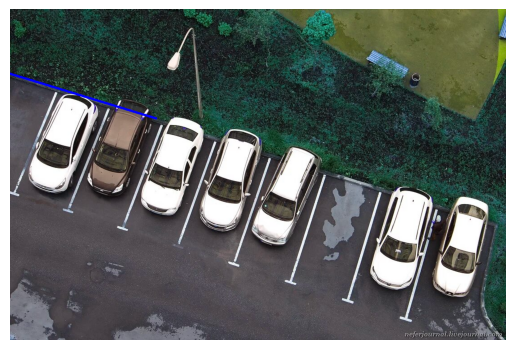

Dominant angle: 16.990823291986175


In [2592]:
def dominant_angle_from_longest_line(lines, image=None):
    """
    lines: output from cv2.HoughLinesP (Nx1x4)
    image: optional BGR image. If supplied, the longest line is drawn in red.

    Returns:
        angle_deg (float) or None
        debug_image (BGR) or None
    """

    if lines is None or len(lines) == 0:
        return None, None if image is not None else None

    longest_len = -1
    longest_line = None

    # --------------------------------------------
    # Find the longest Hough line
    # --------------------------------------------
    for l in lines:
        x1, y1, x2, y2 = l[0]
        length = np.hypot(x2 - x1, y2 - y1)

        if length > longest_len:
            longest_len = length
            longest_line = (x1, y1, x2, y2)

    if longest_line is None:
        return None, None if image is not None else None

    x1, y1, x2, y2 = longest_line

    # --------------------------------------------
    # Compute angle in degrees
    # Normalized to [-90, +90]
    # --------------------------------------------
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    angle = (angle + 90) % 180 - 90
    angle = float(angle)

    # --------------------------------------------
    # Optional: draw longest dominant line
    # --------------------------------------------
    debug_img = None
    if image is not None:
        debug_img = image.copy()
        cv2.line(debug_img, (x1, y1), (x2, y2), (0, 0, 255), 3)
        plt.imshow(debug_img)
        plt.axis('off')
        plt.show()
    
    return angle

angle = dominant_angle_from_longest_line(lines, image=masked_image)
print("Dominant angle:", angle)

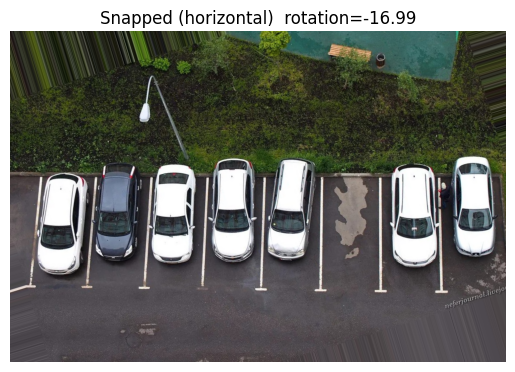

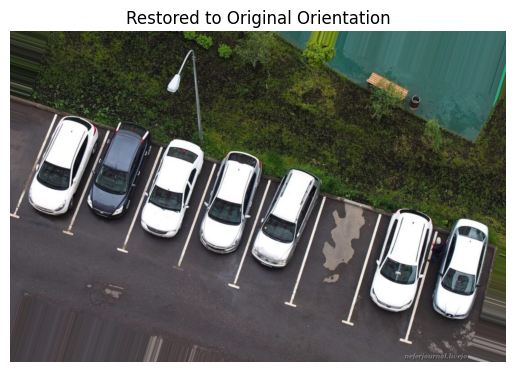

In [2593]:
def rotate_full(image, angle_deg):
    """
    Rotates the image by angle_deg WITHOUT cropping.
    Positive angle rotates CCW visually.
    """
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    # OpenCV rotates visually clockwise for positive angles,
    # so we negate to get normal CCW visuals.
    M = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    rotated = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )

    Minv = cv2.invertAffineTransform(M)

    return rotated, M, Minv



def snap_to_orientation(image, dominant_angle, threshold_deg=0):
    """
    Snaps image to 0° (horizontal) or 90° (vertical) WITHOUT cropping.
    Skips rotation if the required adjustment is below threshold_deg.
    """
    if dominant_angle is None:
        return image, 0, None, None, "none"

    # Determine target orientation
    if abs(dominant_angle) <= 45:
        target = 0
        snapped_to = "horizontal"
    else:
        target = 90 if dominant_angle > 0 else -90
        snapped_to = "vertical"

    rotation_needed = target - dominant_angle

    # ---- NEW: do nothing if rotation is tiny ----
    if abs(rotation_needed) <= threshold_deg:
        print("Didn't Rotate")
        return image, 0, None, None, "none (below threshold)"

    # Perform full rotation
    rotated, M, Minv = rotate_full(image, rotation_needed)

    return rotated, rotation_needed, M, Minv, snapped_to


def restore_original(rotated_image, Minv):
    """
    Uses the inverse rotation matrix to restore the original image.
    If Minv is None (meaning no rotation was applied), simply return the image.
    """
    if Minv is None:
        return rotated_image  # Nothing to undo

    h, w = rotated_image.shape[:2]

    restored = cv2.warpAffine(
        rotated_image, Minv, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )

    return restored
    
def rad2deg(radians):
    return radians * 180.0 / np.pi

snapped, rot_angle, M, Minv, orientation = snap_to_orientation(masked_image, angle)

plt.imshow(snapped[..., ::-1])
plt.title(f"Snapped ({orientation})  rotation={rot_angle:.2f}")
plt.axis('off')
plt.show()

restored = restore_original(snapped, Minv)

plt.imshow(restored[..., ::-1])
plt.title("Restored to Original Orientation")
plt.axis('off')
plt.show()

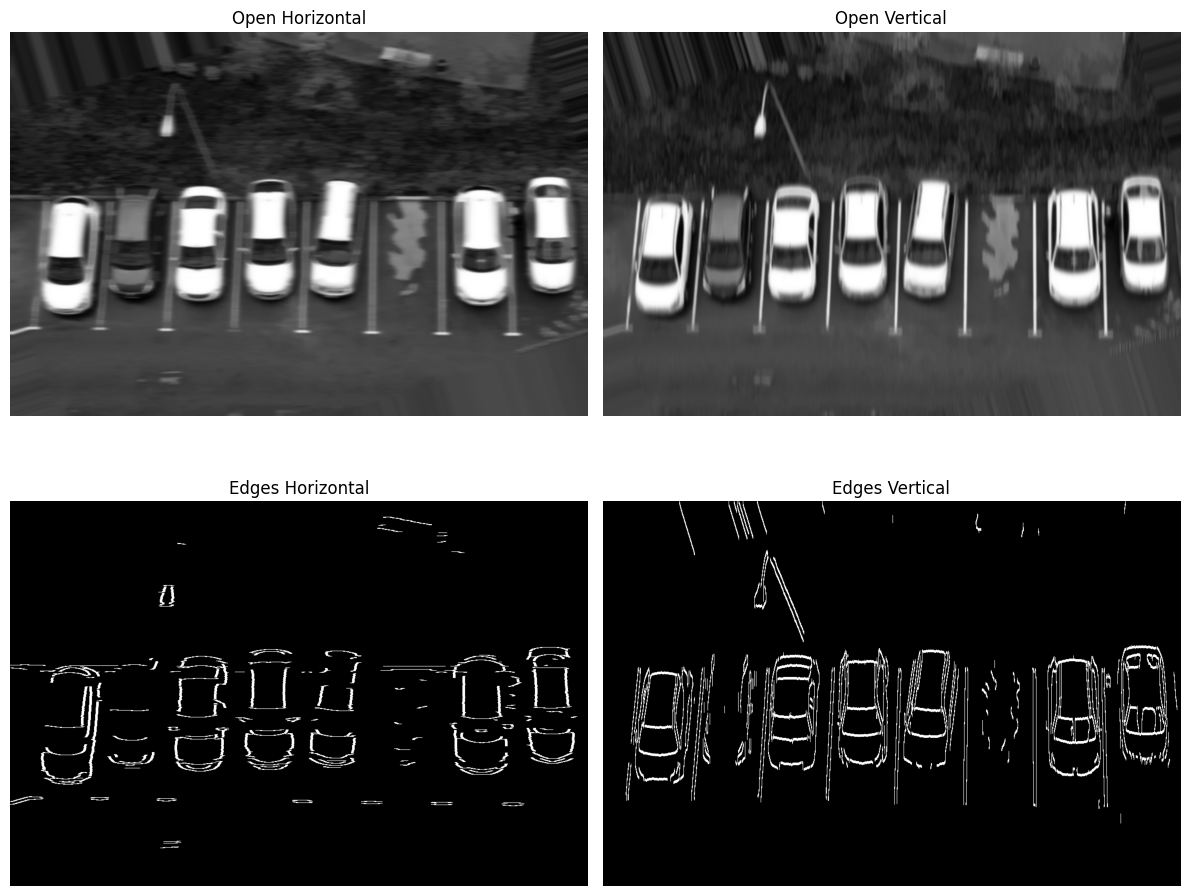

In [2594]:
def step_lines_rotated(image):
    """
    Strong directional line isolation after orientation snapping.
    Uses directional opening and anisotropic blurring.
    Automatically displays intermediate results.
    """

    # ------------------------------------------------------------
    # Greyscale + equalize
    # ------------------------------------------------------------
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    grey_blur_v = cv2.GaussianBlur(grey, (3,21), 0)
    grey_blur_h = cv2.GaussianBlur(grey, (21,3), 0)

    # ------------------------------------------------------------
    # Directional structuring elements
    # ------------------------------------------------------------
    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 1))
    vert_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 11))

    blur_h = cv2.GaussianBlur(grey_blur_h, (21, 3), 0)
    blur_v = cv2.GaussianBlur(grey_blur_v, (3, 21), 0)

    # ------------------------------------------------------------
    # Directional opening (remove noise not aligned to axes)
    # ------------------------------------------------------------
    open_h = cv2.morphologyEx(blur_h, cv2.MORPH_OPEN, horiz_kernel)
    open_v = cv2.morphologyEx(blur_v, cv2.MORPH_OPEN, vert_kernel)

    # ------------------------------------------------------------
    # Adaptive threshold to isolate strong lines
    # ------------------------------------------------------------

    # ------------------------------------------------------------
    # Final edges
    # ------------------------------------------------------------
    # good working one is 90 and 120
    edges_h = cv2.Canny(open_h, 90, 120)
    edges_v = cv2.Canny(open_v, 90, 120)
    
    horiz_thick_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,1))
    edges_h_thick = cv2.dilate(edges_h, horiz_thick_kernel, iterations=1)

    vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,5))
    edges_v_thick = cv2.dilate(edges_v, vert_kernel, iterations=1)
    
    # ------------------------------------------------------------
    # Display results
    # ------------------------------------------------------------


    plt.figure(figsize=(12,10))

    plt.subplot(221)
    plt.imshow(open_h, cmap='gray')
    plt.title("Open Horizontal")
    plt.axis('off')

    plt.subplot(222)
    plt.imshow(open_v, cmap='gray')
    plt.title("Open Vertical")
    plt.axis('off')

    plt.subplot(223)
    plt.imshow(edges_h_thick, cmap='gray')
    plt.title("Edges Horizontal")
    plt.axis('off')
    
    plt.subplot(224)
    plt.imshow(edges_v_thick, cmap='gray')
    plt.title("Edges Vertical")
    plt.axis('off')


    plt.tight_layout()
    plt.show()

    return edges_h_thick, edges_v_thick, open_h, open_v

edges_h, edges_v, open_h, open_v = step_lines_rotated(snapped)

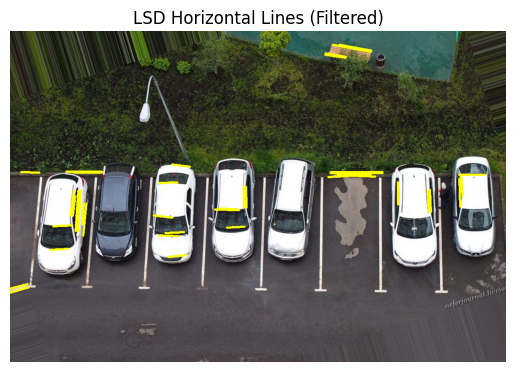

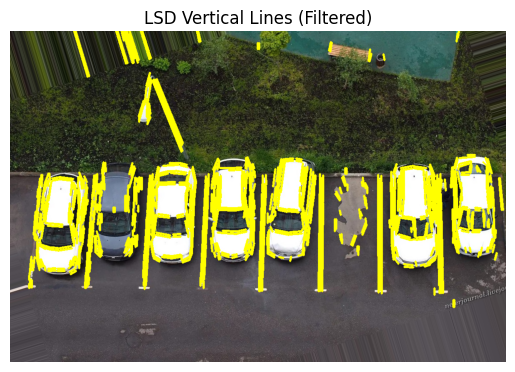

In [2595]:
min_length_h = 80

lsd = cv2.createLineSegmentDetector(refine=cv2.LSD_REFINE_STD)

# Horizontal lines
lines_h = lsd.detect(edges_h)[0]

drawn_h = snapped.copy()

if lines_h is not None:
    for l in lines_h:
        x1, y1, x2, y2 = map(int, l[0])

        # compute line length
        length = np.hypot(x2 - x1, y2 - y1)

        if length >= min_length:     # <–– filter here
            cv2.line(drawn_h, (x1, y1), (x2, y2), (0,255,255), 4)

plt.imshow(drawn_h[..., ::-1])
plt.title("LSD Horizontal Lines (Filtered)")
plt.axis('off')
plt.show()

# -------------------------------------
# Vertical lines (same logic)
# -------------------------------------

min_length_v = 10
lines_v = lsd.detect(edges_v)[0]

drawn_v = snapped.copy()

if lines_v is not None:
    for l in lines_v:
        x1, y1, x2, y2 = map(int, l[0])

        length = np.hypot(x2 - x1, y2 - y1)

        if length >= min_length_v:
            cv2.line(drawn_v, (x1, y1), (x2, y2), (0,255,255), 4)

plt.imshow(drawn_v[..., ::-1])
plt.title("LSD Vertical Lines (Filtered)")
plt.axis('off')
plt.show()

Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 4 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 3 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
Merge group: 2 lines → 1 merged line
M

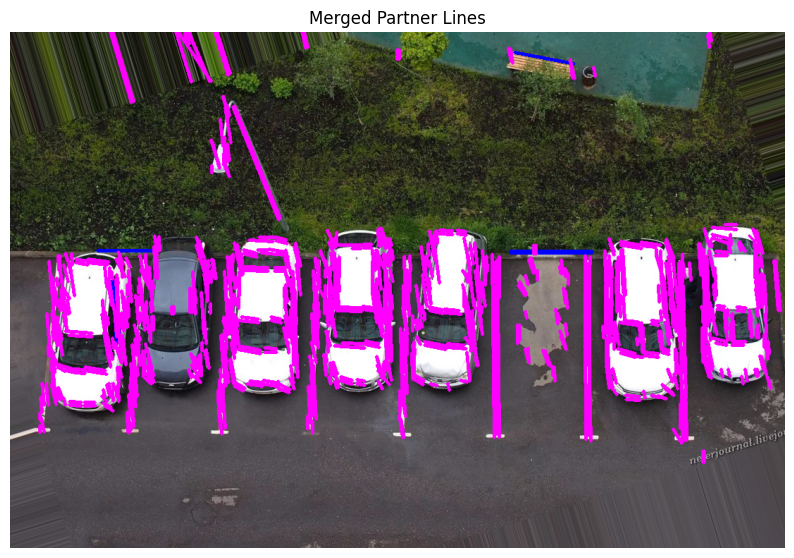

In [2596]:
# =========================================================
# COMBINE PARTNER LINES (horizontal and vertical separately)
# =========================================================

def combine_partner_lines(lines, midpoint_thresh=15, length_ratio=0.15, angle_thresh_deg=5):
    """
    lines: list of (x1, y1, x2, y2)
    Returns merged list of lines and prints merge groups.
    """

    if not lines:
        return []

    # Convert all lines into a useful structure
    processed = []
    for (x1, y1, x2, y2) in lines:
        length = np.hypot(x2 - x1, y2 - y1)
        mid = ((x1 + x2)/2, (y1 + y2)/2)
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))  # angle in degrees
        processed.append({
            "pts": (x1, y1, x2, y2),
            "length": length,
            "mid": mid,
            "angle": angle
        })

    used = set()
    merged = []

    for i in range(len(processed)):
        if i in used:
            continue

        base = processed[i]
        group = [base]
        used.add(i)

        # Compare with all other lines
        for j in range(i+1, len(processed)):
            if j in used:
                continue

            cand = processed[j]

            # Midpoint distance check
            dx = base["mid"][0] - cand["mid"][0]
            dy = base["mid"][1] - cand["mid"][1]
            mid_dist = np.hypot(dx, dy)
            if mid_dist > midpoint_thresh:
                continue

            # Length similarity check
            len_diff_ratio = abs(base["length"] - cand["length"]) / max(base["length"], cand["length"])
            if len_diff_ratio > length_ratio:
                continue

            # Angle similarity check
            if abs(base["angle"] - cand["angle"]) > angle_thresh_deg:
                continue

            # If all checks passed → partner
            group.append(cand)
            used.add(j)

        # Print merge info
        if len(group) > 1:
            print(f"Merge group: {len(group)} lines → 1 merged line")

        # Merge the group into one line (take global min/max extents)
        xs = []
        ys = []
        for g in group:
            x1, y1, x2, y2 = g["pts"]
            xs.extend([x1, x2])
            ys.extend([y1, y2])

        x1m = min(xs)
        x2m = max(xs)
        y1m = min(ys)
        y2m = max(ys)

        merged.append((x1m, y1m, x2m, y2m))

    return merged


# ---------------------------------------------------------
# Apply merging to your filtered horizontal and vertical lines
# ---------------------------------------------------------

# Extract the lines you kept earlier
kept_h = []
if lines_h is not None:
    for l in lines_h:
        x1, y1, x2, y2 = map(int, l[0])
        length = np.hypot(x2 - x1, y2 - y1)
        if length >= min_length_h:
            kept_h.append((x1, y1, x2, y2))

kept_v = []
if lines_v is not None:
    for l in lines_v:
        x1, y1, x2, y2 = map(int, l[0])
        length = np.hypot(x2 - x1, y2 - y1)
        if length >= min_length_v:
            kept_v.append((x1, y1, x2, y2))

# Merge partners
merged_h = combine_partner_lines(kept_h)
merged_v = combine_partner_lines(kept_v)

# ---------------------------------------------------------
# Report merging statistics
# ---------------------------------------------------------

num_input_h = len(kept_h)
num_output_h = len(merged_h)
num_merged_h = num_input_h - num_output_h

num_input_v = len(kept_v)
num_output_v = len(merged_v)
num_merged_v = num_input_v - num_output_v

print("\n========== MERGE SUMMARY ==========")
print("Horizontal lines:")
print(f"  Input:  {num_input_h}")
print(f"  Output: {num_output_h}")
print(f"  Merged: {num_merged_h}")

print("\nVertical lines:")
print(f"  Input:  {num_input_v}")
print(f"  Output: {num_output_v}")
print(f"  Merged: {num_merged_v}")
print("===================================")


# ---------------------------------------------------------
# Draw merged horizontal and vertical lines for inspection
# ---------------------------------------------------------

drawn_merged = snapped.copy()

# Draw merged horizontal (blue)
for (x1, y1, x2, y2) in merged_h:
    cv2.line(drawn_merged, (x1, y1), (x2, y2), (255,0,0), 4)

# Draw merged vertical (magenta)
for (x1, y1, x2, y2) in merged_v:
    cv2.line(drawn_merged, (x1, y1), (x2, y2), (255,0,255), 4)

plt.figure(figsize=(10,10))
plt.imshow(drawn_merged[..., ::-1])
plt.title("Merged Partner Lines")
plt.axis('off')
plt.show()


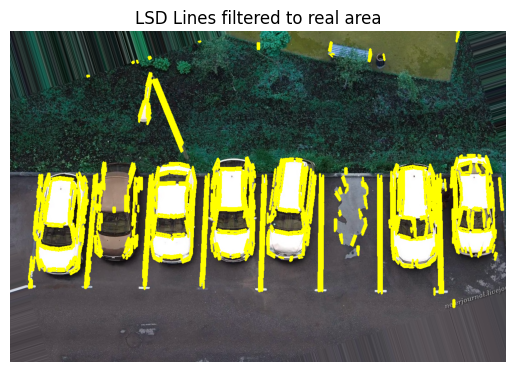

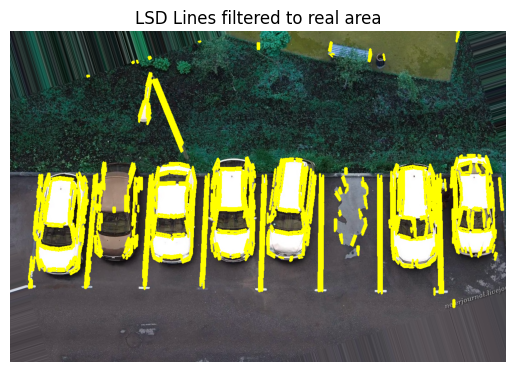

In [2597]:
def get_original_polygon_after_rotation(w, h, M):
    """
    Compute the 4 corner points of the original (unrotated) image
    mapped into the rotated (snapped) image using M.
    Returns a (4,2) float32 array.
    """
    # Original image corners in (x, y)
    corners = np.array([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ], dtype=np.float32)

    # Homogeneous coords: (x, y, 1)
    ones = np.ones((4, 1), dtype=np.float32)
    corners_h = np.hstack([corners, ones])      # (4, 3)

    # Apply affine transform: (4,3) @ (3,2).T → (4,2)
    poly = corners_h @ M.T

    return poly.astype(np.float32)

def clip_line_to_polygon(x1, y1, x2, y2, poly):
    """
    Clips a line segment to a convex polygon.
    Returns (x1c, y1c, x2c, y2c, valid)
    """

    # Represent line as two points
    p1 = np.array([x1, y1], dtype=np.float32)
    p2 = np.array([x2, y2], dtype=np.float32)

    # Early exit if both points are outside and on same side
    # (Optional – full clip handles it)
    
    # Clip using Liang-Barsky for convex polygons
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    t0, t1 = 0.0, 1.0

    for i in range(len(poly)):
        # Current polygon edge
        x3, y3 = poly[i]
        x4, y4 = poly[(i + 1) % len(poly)]

        # Edge normal (pointing inward)
        nx = y4 - y3
        ny = -(x4 - x3)

        # Compute dot products
        numerator = nx * (x3 - p1[0]) + ny * (y3 - p1[1])
        denominator = nx * dx + ny * dy

        if denominator == 0:
            # Line is parallel to this edge
            if numerator < 0:
                return 0, 0, 0, 0, False
            else:
                continue

        t = numerator / denominator

        if denominator < 0:
            # entering
            if t > t0:
                t0 = t
        else:
            # leaving
            if t < t1:
                t1 = t

        if t0 > t1:
            return 0, 0, 0, 0, False

    # Compute clipped points
    q1 = p1 + t0 * np.array([dx, dy])
    q2 = p1 + t1 * np.array([dx, dy])

    return int(q1[0]), int(q1[1]), int(q2[0]), int(q2[1]), True

h0, w0 = image.shape[:2]

if M is not None:
    
    poly = get_original_polygon_after_rotation(w0, h0, M)

    bounded_v_lines = []
    
    for l in lines_v:
        x1, y1, x2, y2 = map(int, l[0])
        x1c, y1c, x2c, y2c, valid = clip_line_to_polygon(x1, y1, x2, y2, poly)
        if valid:
            bounded_v_lines.append((x1c, y1c, x2c, y2c))
    
    drawn = snapped.copy()
    for x1, y1, x2, y2 in bounded_v_lines:
        cv2.line(drawn, (x1, y1), (x2, y2), (255,255,0), 4)
    
    plt.imshow(drawn)
    plt.title("LSD Lines filtered to real area")
    plt.axis('off')
    plt.show()

else:
    print("Not filtering")
    bounded_v_lines = []
    for l in lines_v:
        x1, y1, x2, y2 = map(int, l[0])
        bounded_v_lines.append((x1, y1, x2, y2))

drawn = snapped.copy()
for x1, y1, x2, y2 in bounded_v_lines:
    cv2.line(drawn, (x1, y1), (x2, y2), (255,255,0), 4)

plt.imshow(drawn)
plt.title("LSD Lines filtered to real area")
plt.axis('off')
plt.show()

Initial clusters: 8
After Y-gap splitting (before size filter): 8
  C0: size=2, Y-range=7.0..14.0
  C1: size=4, Y-range=33.0..35.0
  C2: size=3, Y-range=53.0..58.5
  C3: size=3, Y-range=106.5..112.5
  C4: size=2, Y-range=133.0..144.0
  C5: size=14, Y-range=160.5..198.0
  C6: size=726, Y-range=288.0..576.5
  C7: size=2, Y-range=603.0..603.0
After size filter (>= min_cluster_size): 2
  Row 0: size=14, Y-range=160.5..198.0
  Row 1: size=726, Y-range=288.0..576.5


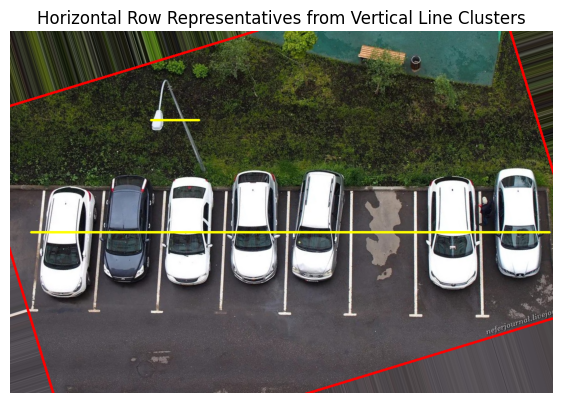

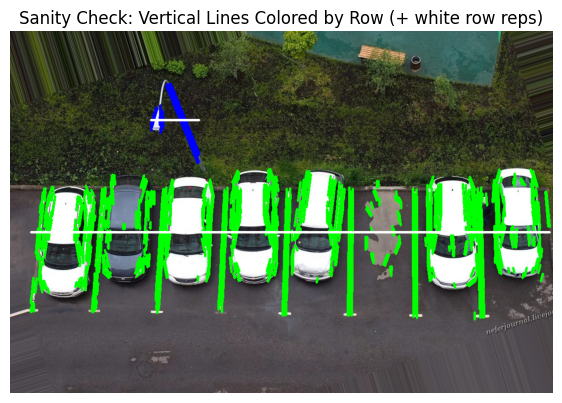

In [2598]:
# ==========================
# PARAMS
# ==========================
cluster_thresh     = 12   # lines closer than this in Y go into same initial cluster
gap_thresh         = 30   # if gap between consecutive lines in cluster > this → split
min_vertical_length = 10  # drop very short verticals
min_cluster_size    = 6   # drop clusters with fewer than this many lines (noise)


# =========================================================
# 1) FILTER LINES & ATTACH Y FEATURES
# =========================================================
# bounded_v_lines: list of (x1,y1,x2,y2) vertical-ish lines in snapped image

lines_with_y = []   # (y_mid, length, (x1,y1,x2,y2))

for (x1, y1, x2, y2) in bounded_v_lines:
    length = abs(y2 - y1)

    if length < min_vertical_length:
        continue

    y_mid = 0.5 * (y1 + y2)
    lines_with_y.append((y_mid, length, (x1, y1, x2, y2)))

# sort by Y for stable clustering
lines_with_y.sort(key=lambda x: x[0])


# =========================================================
# 2) INITIAL CLUSTERING BY LOCAL Y PROXIMITY (cluster_thresh)
# =========================================================
clusters = []
current  = []

for y, length, line in lines_with_y:
    if not current:
        current.append((y, length, line))
        continue

    last_y = current[-1][0]
    if abs(y - last_y) <= cluster_thresh:
        current.append((y, length, line))
    else:
        clusters.append(current)
        current = [(y, length, line)]

if current:
    clusters.append(current)

print("Initial clusters:", len(clusters))


# =========================================================
# 3) SPLIT CLUSTERS BY Y-GAP RULE (gap_thresh)
# =========================================================
def split_cluster_on_y_gaps(cluster, gap_thresh):
    """
    cluster: list of (y_mid, length, (x1,y1,x2,y2))
    returns list of subclusters.
    """
    cluster_sorted = sorted(cluster, key=lambda e: e[0])
    subclusters = []
    current = [cluster_sorted[0]]

    for i in range(1, len(cluster_sorted)):
        prev_y = cluster_sorted[i-1][0]
        this_y = cluster_sorted[i][0]
        gap = abs(this_y - prev_y)

        if gap <= gap_thresh:
            current.append(cluster_sorted[i])
        else:
            subclusters.append(current)
            current = [cluster_sorted[i]]

    if current:
        subclusters.append(current)

    return subclusters


final_clusters = []
for c in clusters:
    if len(c) <= 1:
        continue
    pieces = split_cluster_on_y_gaps(c, gap_thresh)
    final_clusters.extend(pieces)

print("After Y-gap splitting (before size filter):", len(final_clusters))
for i, c in enumerate(final_clusters):
    ys = [e[0] for e in c]
    print(f"  C{i}: size={len(c)}, Y-range={min(ys):.1f}..{max(ys):.1f}")


# =========================================================
# 4) DROP SMALL CLUSTERS (road-marking junk, noise)
# =========================================================
final_clusters = [c for c in final_clusters if len(c) >= min_cluster_size]

print("After size filter (>= min_cluster_size):", len(final_clusters))
for i, c in enumerate(final_clusters):
    ys = [e[0] for e in c]
    print(f"  Row {i}: size={len(c)}, Y-range={min(ys):.1f}..{max(ys):.1f}")


# =========================================================
# 5) BUILD HORIZONTAL ROW REPRESENTATIVES
# =========================================================
horizontal_row_lines = []   # (x1, y_mid, x2, y_mid)

for cluster in final_clusters:
    # all original lines in this row
    xs = []
    y_mids = []

    for (y_mid, length, (x1, y1, x2, y2)) in cluster:
        xs.extend([x1, x2])
        y_mids.append(y_mid)

    # representative Y: average of midpoints in the row
    row_y = int(np.mean(y_mids))

    # horizontal span across all verticals
    min_x = int(min(xs))
    max_x = int(max(xs))

    horizontal_row_lines.append((min_x, row_y, max_x, row_y))


# =========================================================
# 6) DRAW: ROW REPRESENTATIVES
# =========================================================
drawn = snapped.copy()
if M is not None and 'poly' in globals():
    poly_int = poly.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(drawn, [poly_int], True, (0, 0, 255), 3)

for (x1, y1, x2, y2) in horizontal_row_lines:
    cv2.line(drawn, (x1, y1), (x2, y2), (0, 255, 255), 4)

plt.figure(figsize=(7, 7))
plt.imshow(drawn[..., ::-1])
plt.title("Horizontal Row Representatives from Vertical Line Clusters")
plt.axis('off')
plt.show()


# =========================================================
# 7) SANITY CHECK: DRAW VERTICAL LINES BY ROW GROUP
# =========================================================
row_colors = [
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 255),
    (255, 255, 0),
    (255, 0, 255),
    (0, 255, 255),
]

debug = snapped.copy()

for row_idx, cluster in enumerate(final_clusters):
    color = row_colors[row_idx % len(row_colors)]
    for (y_mid, length, (x1, y1, x2, y2)) in cluster:
        cv2.line(debug, (x1, y1), (x2, y2), color, 3)

# overlay horizontal row lines in white
for (x1, y1, x2, y2) in horizontal_row_lines:
    cv2.line(debug, (x1, y1), (x2, y2), (255, 255, 255), 4)

plt.figure(figsize=(7, 7))
plt.imshow(debug[..., ::-1])
plt.title("Sanity Check: Vertical Lines Colored by Row (+ white row reps)")
plt.axis('off')
plt.show()


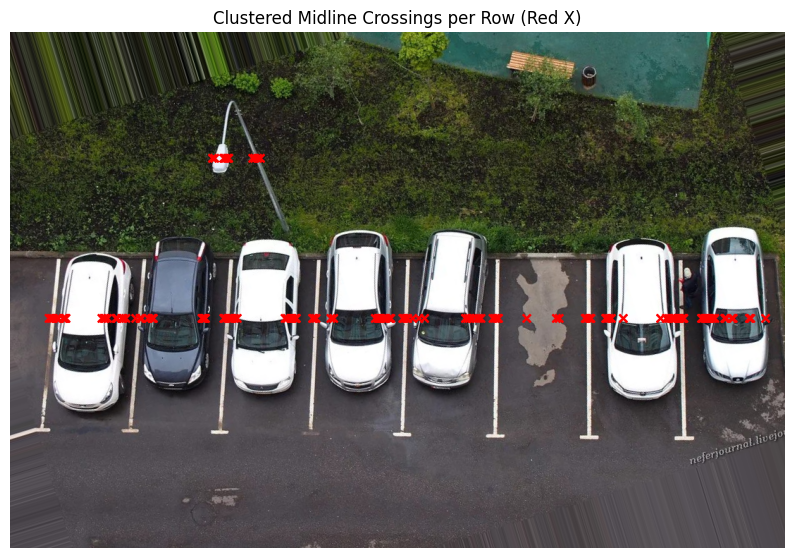

Row midlines (Y): [180, 407]
Clustered midline crossings per row:
Row 0 (Y=180): [287.8285714285714, 290.8888888888889, 303.0, 305.0, 308.375, 310.60869565217394, 344.5350318471338, 347.56962025316454, 351.70344827586206, 355.22535211267603]
Row 1 (Y=407): [55.450980392156865, 58.38461538461539, 61.25, 66.78571428571429, 68.88888888888889, 75.08108108108108, 77.29411764705883, 79.45454545454545, 130.0, 133.0, 134.0, 135.0, 138.8181818181818, 150.05263157894737, 152.54545454545453, 158.0, 160.85714285714286, 164.05405405405406, 178.78048780487805, 184.33333333333334, 186.54545454545453, 196.52, 201.0, 203.0, 272.53333333333336, 274.0, 275.8421052631579, 277.7692307692308, 303.8, 305.8666666666667, 309.07142857142856, 311.44827586206895, 315.5892857142857, 318.0, 322.8333333333333, 390.6666666666667, 393.0487804878049, 398.3170731707317, 400.0, 404.375, 406.62068965517244, 429.64102564102564, 431.86486486486484, 434.7, 455.2857142857143, 459.4390243902439, 518.7058823529412, 522.22222222

In [2599]:
# =========================================================
# 0) COMPUTE MIDLINE CROSSINGS PER ROW (LENGTH-WEIGHTED + ANGLE)
# =========================================================

row_midlines = []
row_crossings = []    # list of lists of (x_cross, weight, angle_deg)

for cluster in final_clusters:
    # midline Y
    y_mids = [e[0] for e in cluster]
    mid_y = int(np.mean(y_mids))
    row_midlines.append(mid_y)

    crossings = []

    for (y_mid, length, (x1, y1, x2, y2)) in cluster:
        if y2 == y1:
            continue

        # compute parametric crossing t
        t = (mid_y - y1) / (y2 - y1)
        if 0 <= t <= 1:
            x_cross = x1 + t * (x2 - x1)
            weight = abs(y2 - y1)

            # compute angle with respect to horizontal
            dx = x2 - x1
            dy = y2 - y1
            angle_deg = np.degrees(np.arctan2(dy, dx))

            crossings.append((x_cross, weight, angle_deg))

    crossings.sort(key=lambda p: p[0])
    row_crossings.append(crossings)



# =========================================================
# 1) CLUSTER WITH LENGTH WEIGHTING
# =========================================================

# cluster_thresh = 20
# clustered_rows = []   # each row = list of length-weighted cluster center x's

# for crossings in row_crossings:

#     if not crossings:
#         clustered_rows.append([])
#         continue

#     merged = []
#     current = [crossings[0]]  # list of (x, w) pairs

#     for (x, w) in crossings[1:]:
#         last_x, _ = current[-1]

#         if abs(x - last_x) <= cluster_thresh:
#             current.append((x, w))
#         else:
#             # finalize group → weighted mean
#             xs = [p[0] for p in current]
#             ws = [p[1] for p in current]
#             weighted_center = int(np.average(xs, weights=ws))
#             merged.append(weighted_center)

#             current = [(x, w)]

#     # flush final group
#     xs = [p[0] for p in current]
#     ws = [p[1] for p in current]
#     weighted_center = int(np.average(xs, weights=ws))
#     merged.append(weighted_center)

#     clustered_rows.append(merged)

# =========================================================
# 1) DO NOT CLUSTER — USE RAW MIDLINE CROSSINGS
# =========================================================

clustered_rows = []     # X only
clustered_angles = []   # angle only

for crossings in row_crossings:
    xs     = [x for (x, w, ang) in crossings]
    angles = [ang for (x, w, ang) in crossings]

    clustered_rows.append(xs)
    clustered_angles.append(angles)



# =========================================================
# 2) DRAW EACH ROW'S CLUSTERED MIDLINE CROSSINGS AS "X"
# =========================================================

drawn = snapped.copy()

for row_idx, xs in enumerate(clustered_rows):
    y = row_midlines[row_idx]
    for x in xs:
        x_int = int(x)
        y_int = int(y)

        # draw an "X" centered at (x, y)
        cv2.line(drawn, (x_int-5, y_int-5), (x_int+5, y_int+5), (0,0,255), 2)
        cv2.line(drawn, (x_int-5, y_int+5), (x_int+5, y_int-5), (0,0,255), 2)

plt.figure(figsize=(10,10))
plt.imshow(drawn[..., ::-1])
plt.title("Clustered Midline Crossings per Row (Red X)")
plt.axis('off')
plt.show()



# =========================================================
# 3) PRINT CLUSTER CENTERS PER ROW
# =========================================================

print("Row midlines (Y):", row_midlines)
print("Clustered midline crossings per row:")
for i, xs in enumerate(clustered_rows):
    print(f"Row {i} (Y={row_midlines[i]}): {xs}")

# =========================================================
# 4) FIND THE GLOBAL MODAL STALL SPACING (all rows combined)
# =========================================================

from collections import Counter

all_gaps = []

for xs in clustered_rows:
    if len(xs) < 2:
        continue
    gaps = [xs[i+1] - xs[i] for i in range(len(xs) - 1)]
    all_gaps.extend(gaps)

if not all_gaps:
    print("No gaps found.")
else:
    gap_counts = Counter(all_gaps)
    modal_gap, modal_count = gap_counts.most_common(1)[0]

    print("\n=== GLOBAL MODAL GAP ACROSS ALL ROWS ===")
    print("All unique gaps:", sorted(gap_counts.items(), key=lambda x: x[0]))
    print("Modal gap:", modal_gap, "px   (frequency:", modal_count, ")")

Removed box row 0: width 68 < 128.0
Height: 256


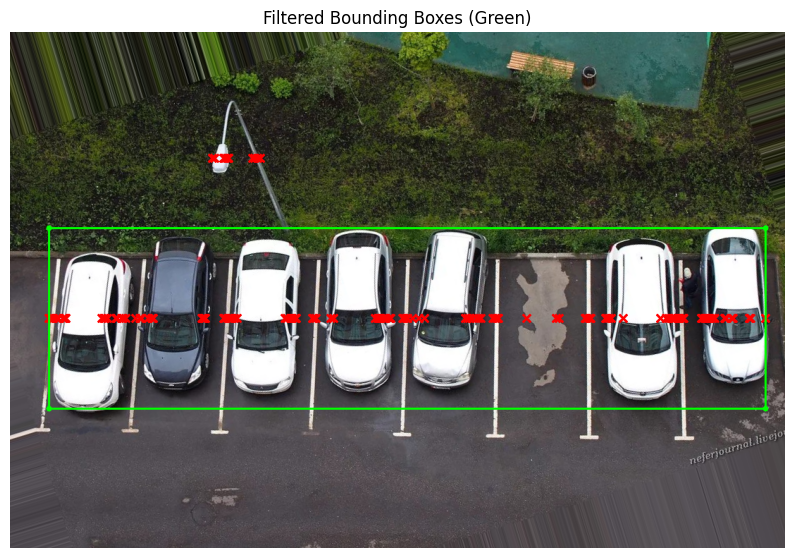

In [2600]:
# =========================================================
# 5) DRAW A SYMMETRIC BOUNDING BOX BASED ON CROSSING POINTS
# =========================================================

boxed = drawn.copy()

all_boxes = []   # store (row_idx, min_x, min_y, max_x, max_y)

for row_idx, cluster in enumerate(final_clusters):

    crossings = clustered_rows[row_idx]
    if len(crossings) == 0:
        continue

    # Horizontal limits
    min_x = int(min(crossings))
    max_x = int(max(crossings))

    # Raw vertical extents
    xs_tmp = []
    ys_tmp = []
    for (y_mid, length, (x1, y1, x2, y2)) in cluster:
        xs_tmp.extend([x1, x2])
        ys_tmp.extend([y1, y2])

    if not ys_tmp:
        continue

    min_y_raw = min(ys_tmp)
    max_y_raw = max(ys_tmp)

    # Symmetric vertical expansion
    mid_y = row_midlines[row_idx]
    above = mid_y - min_y_raw
    below = max_y_raw - mid_y
    expansion = min(above, below)

    min_y = int(mid_y - expansion)
    max_y = int(mid_y + expansion)

    # Store for later filtering
    all_boxes.append((row_idx, min_x, min_y, max_x, max_y))


# =========================================================
# 6) FILTER BOXES BY HEIGHT (remove small ones)
# =========================================================

if all_boxes:
    heights = [(max_y - min_y) for (_, _, min_y, _, max_y) in all_boxes]
    max_height = max(heights)
    cutoff = 0.35 * max_height

    # Base height filtering
    filtered_boxes = [
        box for box, h in zip(all_boxes, heights)
        if h >= cutoff
    ]
else:
    filtered_boxes = []


# =========================================================
# >>> NEW FILTER: DELETE BOXES WITH WIDTH < 0.5 * max_height
# =========================================================

if filtered_boxes:
    final_boxes = []
    for (row_idx, min_x, min_y, max_x, max_y) in filtered_boxes:

        width = max_x - min_x
        if width >= 0.5 * max_height:
            final_boxes.append((row_idx, min_x, min_y, max_x, max_y))
        else:
            print(f"Removed box row {row_idx}: width {width} < {0.5*max_height}")

else:
    final_boxes = []


# Replace filtered_boxes with final_boxes for drawing
filtered_boxes = final_boxes


# =========================================================
# 7) DRAW REMAINING BOXES
# =========================================================

for (_, min_x, min_y, max_x, max_y) in filtered_boxes:

    NW = (min_x, min_y)
    NE = (max_x, min_y)
    SW = (min_x, max_y)
    SE = (max_x, max_y)

    cv2.line(boxed, NW, NE, (0,255,0), 2)
    cv2.line(boxed, SW, SE, (0,255,0), 2)
    cv2.line(boxed, NW, SW, (0,255,0), 2)
    cv2.line(boxed, NE, SE, (0,255,0), 2)

    cv2.circle(boxed, NW, 4, (0,255,0), -1)
    cv2.circle(boxed, NE, 4, (0,255,0), -1)
    cv2.circle(boxed, SW, 4, (0,255,0), -1)
    cv2.circle(boxed, SE, 4, (0,255,0), -1)



    row_height = max_y - min_y
    print(f"Height: {row_height}")

plt.figure(figsize=(10,10))
plt.imshow(boxed[..., ::-1])
plt.title("Filtered Bounding Boxes (Green)")
plt.axis('off')
plt.show()